In [1]:
## detail see our stuff here: https://mesa-py.readthedocs.io/en/latest/

import numpy as np
import pandas as pd
import anndata as ad
import seaborn as sns
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.figure import figaspect
from scipy.stats import ranksums
import itertools

import os
#os.sys.path.append('../../../')
from mesa import ecospatial as eco

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
/Users/bokaizhu/anaconda3/envs/mesa/lib/python3.10/site-packages/spaghetti/network.py:41: FutureWarning: The next major release of pysal/spaghetti (2.0.0) will drop support for all ``libpysal.cg`` geometries. This change is a first step in refactoring ``spaghetti`` that is expected to result in dramatically reduced runtimes for network instantiation and operations. Users currently requiring network and point pattern input as ``libpysal.cg`` geometries should prepare for this simply by converting to ``shapely`` geometries.
  warnings.warn(dep_msg, FutureWarning, stacklevel=1)
/Users/bokaizhu/anaconda3/envs/mesa/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
### read in the protein data

path = '../data/Pro_normed_counts&meta_final.csv'
df_all_anno = pd.read_csv(path)
df_all_anno['tma_fov'] = df_all_anno['TMA.y'].astype(str) + '_' + df_all_anno['FOV_RNA'].astype(str)
#df_all_anno.phenoShort.value_counts()
#df_all_anno.head()

/var/folders/3_/pf5ff_p57fqfsm6w00s_hg480000gn/T/ipykernel_66773/1565661203.py:4: DtypeWarning: Columns (79,92,95,96,98,99,100,101,106,108,109,114,115,130,131,132,133,134,135,136,140,141,143,144,146,147,148,150,151,152,154,155,157,158,163,164,165,166,167,168,169,170) have mixed types. Specify dtype option on import or set low_memory=False.
  df_all_anno = pd.read_csv(path)


In [5]:
# Define tumor-related labels
tumor_labels = [
    "Carcinoma",
    "Spindle carcinoma vs sarcoma",
    "Sarcoma",
    "Rhabdomyosarcoma",
    "HG sarcoma vs PD carcinoma"
]

# Create a new column with binned values
df_all_anno['phenoBin'] = df_all_anno['phenoShort'].apply(
    lambda x: "Tumor" if x in tumor_labels else x
)


In [6]:
meta_data = pd.read_csv("../data/RNA_meta_final.csv")
temp = meta_data.loc[:,['tma_fov', 'MS']].drop_duplicates()
temp2 = df_all_anno.loc[:,['tma_fov', 'MS']].drop_duplicates()
#temp

/var/folders/3_/pf5ff_p57fqfsm6w00s_hg480000gn/T/ipykernel_66773/3635593190.py:1: DtypeWarning: Columns (30,31,32,35,36,38,39,40,41,43,44,46,48,49,50,51,54,55,59,66,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,90,91,92,94,95,96,97,98,100,104,105,106,107,108,109,110,111,113) have mixed types. Specify dtype option on import or set low_memory=False.
  meta_data = pd.read_csv("../../../../../-2024_prev/previous/local_code/other/data/tmall_meta_Jan26_nbhd_clinical.csv")


#### some quick paramter setting for plotting

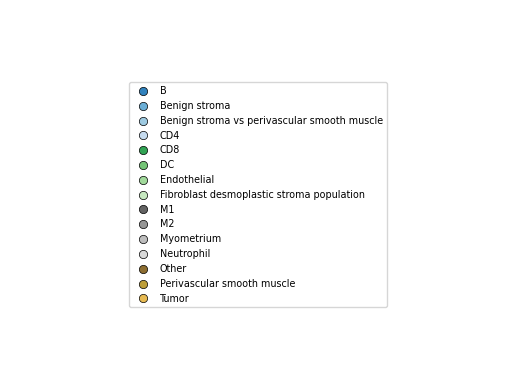

In [7]:
from matplotlib import colors as mcolors
from matplotlib import colormaps

cell_names = sorted(df_all_anno['phenoBin'].unique().tolist())
tab10 = colormaps['tab10']
tab20b = colormaps['tab20b']
tab20c = colormaps['tab20c']

# Extract specific colors by indexing into the colormap (values from 0 to 1)
# From tab20b: indices 8 to 19
colors_from_tab20b = [tab20b(i) for i in range(8, 20)] + [tab20b(0),tab20b(3),tab20b(4),tab20b(5)]
# From tab20c: indices 0-3, 8-11, and 16-19
colors_from_tab20c = [tab20c(i) for i in range(4)] + [tab20c(i) for i in range(8, 12)] + [tab20c(i) for i in range(16, 20)]


# Combine the colors into a custom palette
custom_palette = colors_from_tab20c + colors_from_tab20b

colors_hex = [mcolors.rgb2hex(color) for color in custom_palette]
color_dict = dict(zip(cell_names, colors_hex))
fig, ax = plt.subplots()

for label, color in color_dict.items():
    ax.scatter([], [], c=color, label=label, marker='o',edgecolors='black', linewidths=0.5)

ax.legend(loc='center', ncol=1, fontsize='x-small')
ax.axis('off')
plt.show()

#### tesselation

In [8]:
%%capture
# Define the sequence of scales
scales = [2., 4., 8., 16., 24., 32., 48., 64.]
library_ids = df_all_anno['tma_fov'].unique().tolist()

mdi_results = eco.calculate_MDI(spatial_data=df_all_anno,
                                scales=scales,
                                library_key='tma_fov',
                                library_id=library_ids,
                                spatial_key=['X_cent','Y_cent'],
                                cluster_key='phenoBin',
                                selecting_scale=True,
                                random_patch=False,
                                plotfigs=False,
                                savefigs=False,
                                patch_kwargs={'max_overlap':0.5,'random_seed': 42, 'min_points':2},
                                other_kwargs={'metric': 'Shannon Diversity'})

In [10]:
df_melted = pd.melt(mdi_results,value_vars=scales,
                    var_name='Scale', value_name='Diversity Value')
df_melted

,Scale,Diversity Value
0,2.0,-0.333333
1,2.0,-0.333333
2,2.0,-0.333333
3,2.0,-0.333333
4,2.0,-0.333333
...,...,...
315,64.0,0.097777
316,64.0,0.138313
317,64.0,0.104966
318,64.0,0.061099


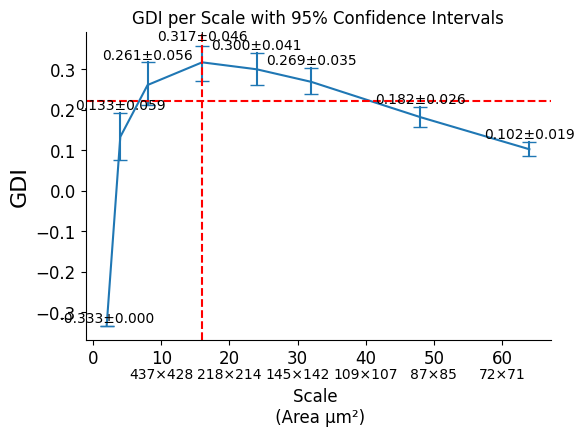

In [11]:
xrange = []
yrange = []
for region in df_all_anno['tma_fov'].unique():
    spatial_value = df_all_anno[df_all_anno['tma_fov']==region][['X_cent','Y_cent']]
    xrange.append(spatial_value.max(axis=0)['X_cent'] - spatial_value.min(axis=0)['X_cent'])
    yrange.append(spatial_value.max(axis=0)['Y_cent'] - spatial_value.min(axis=0)['Y_cent'])
mean_xrange = np.mean(xrange)
std_xrange = np.std(xrange)
mean_yrange = np.mean(yrange)
std_yrange = np.std(yrange)

# Calculate mean and confidence interval
grouped = df_melted.groupby('Scale')
mean_values = grouped['Diversity Value'].mean()
conf_intervals = grouped['Diversity Value'].apply(lambda x: stats.sem(x) * stats.t.ppf((1 + 0.95) / 2., len(x)-1))

# Plotting using sns.lineplot
plt.figure(figsize=(6, 4))
ax = sns.lineplot(data=df_melted,
                  x='Scale',
                  y='Diversity Value',
                  markers=True,
                  estimator='mean',
                  err_style='bars',
                  errorbar=("ci", 95),
                  err_kws={"capsize":5.0}
                 )

# Annotating error bars with their value
for i, (scale, mean, ci) in enumerate(zip(mean_values.index, mean_values, conf_intervals)):
    ax.text(scale, mean + ci, f'{mean:.3f}±{ci:.3f}', color='black', ha='center', va='bottom')

# Drawing red dashed horizontal lines at half the maximum of x and y axes
mean_diversity_per_scale = df_melted.groupby('Scale')['Diversity Value'].mean()
y_sep = mean_diversity_per_scale.median()
x_sep = mean_diversity_per_scale.idxmax()

ax.axhline(y_sep, color='red', linestyle='--')
ax.axvline(x_sep, color='red', linestyle='--')
#ax.get_legend().remove()

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xlabel('', fontsize=0)
plt.xticks(fontsize=12)
plt.ylabel(f"GDI", fontsize=16)
plt.yticks(fontsize=12)

# Add secondary x-axis
xtick_labels = [tick.get_text() for tick in ax.get_xticklabels()][2:-1]
scales = [int(label) for label in xtick_labels if label.strip() != '']
x_sizes = [mean_xrange / scale for scale in scales]
y_sizes = [mean_yrange / scale for scale in scales]
size_labels = [f"{int(x_size)}×{int(y_size)}" for x_size, y_size in zip(x_sizes, y_sizes)]
secax = ax.secondary_xaxis(location=-0.075)
secax.set_xticks(scales)
secax.set_xticklabels(size_labels)
secax.tick_params('x', length=0)
secax.spines['bottom'].set_linewidth(0)
secax.set_xlabel(f'Scale \n (Area μm²)', fontsize=12)

plt.title(f'GDI per Scale with 95% Confidence Intervals')
plt.grid(False)
fig = plt.gcf()
plt.show()

### testing one sample finished - do on all samples?

In [12]:
%%capture
library_ids = df_all_anno['tma_fov'].unique().tolist()

# Define the sequence of scales
scales = [1., 2., 4., 8., 16., 32.]

mdi_results = eco.calculate_MDI(spatial_data=df_all_anno,
                               scales=scales,
                               library_key='tma_fov',
                               library_id=library_ids,
                               spatial_key=['X_cent','Y_cent'],
                               cluster_key='phenoBin',
                               selecting_scale=False,
                               random_patch=False,
                               plotfigs=False,
                               savefigs=False,
                               patch_kwargs={'random_seed': None, 'min_points':2},
                               other_kwargs={'metric': 'Shannon Diversity'})

In [13]:
region_to_patient = dict(zip(df_all_anno["tma_fov"], df_all_anno["patientID"]))
region_to_condition = dict(zip(df_all_anno["tma_fov"], df_all_anno["MS"]))
condition_num2str = {2:'MMR', 3:'p53', 4:'NSMP'}

In [14]:
mdi_results['patientID'] = mdi_results.index.map(region_to_patient)
mdi_results['MS'] = mdi_results.index.map(region_to_condition)
mdi_results['MS2'] = 'non p53'
mdi_results.loc[mdi_results.MS == 3,'MS2'] = 'p53'

#mdi_results

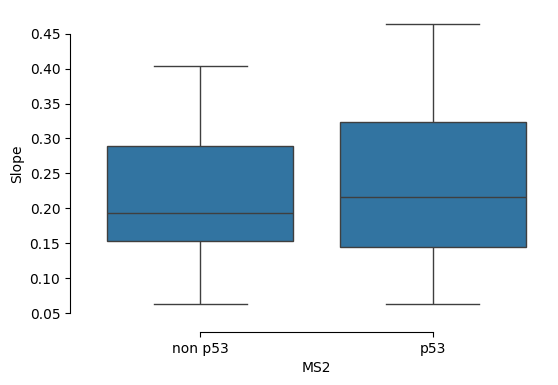

In [15]:
# Create the boxplot
plt.figure(figsize=(6, 4))
ax = sns.boxplot(data=mdi_results, x="MS2", y="Slope")
sns.despine(offset=10, trim=True)

In [16]:
d1 = mdi_results.loc[mdi_results.MS2 == 'non p53','Slope']
d2 = mdi_results.loc[mdi_results.MS2 == 'p53','Slope']
stat, p = ranksums(d1, d2)
p

np.float64(0.6945281474903864)

#### GDI analysis

In [17]:
%%capture
gdi_results = eco.calculate_GDI(spatial_data=df_all_anno,
                                scale=32.0,
                                library_key='tma_fov',
                                library_id=library_ids,
                                spatial_key=['X_cent','Y_cent'],
                                cluster_key='phenoBin',
                                hotspot=True,
                                restricted=False,
                                metric='Shannon Diversity')

In [18]:
gdi_results['patientID'] = gdi_results.index.map(region_to_patient)
gdi_results['MS'] = gdi_results.index.map(region_to_condition)
gdi_results['MS2'] = 'non p53'
gdi_results.loc[gdi_results.MS == 3,'MS2'] = 'p53'

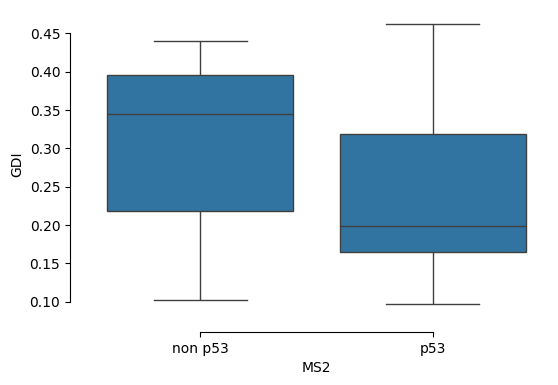

In [19]:
# Create the boxplot
plt.figure(figsize=(6, 4))
ax = sns.boxplot(data=gdi_results, x="MS2", y="GDI")
sns.despine(offset=10, trim=True)

In [20]:
d1 = gdi_results.loc[gdi_results.MS2 == 'non p53','GDI']
d2 = gdi_results.loc[gdi_results.MS2 == 'p53','GDI']
stat, p = ranksums(d1, d2)
p

np.float64(0.07606319671760275)

### DPI metrics

In [21]:
%%capture
# Calculate DPI for hotspots
dpi_results = eco.calculate_DPI(spatial_data=df_all_anno,
                                scale=32.0,
                                library_key='tma_fov',
                                library_id=library_ids,
                                spatial_key=['X_cent','Y_cent'],
                                cluster_key='phenoBin',
                                hotspot=True,
                                metric='Shannon Diversity')
dpi_results

In [22]:
dpi_results['patientID'] = dpi_results.index.map(region_to_patient)
dpi_results['MS'] = dpi_results.index.map(region_to_condition)
dpi_results['MS2'] = 'non p53'
dpi_results.loc[dpi_results.MS == 3,'MS2'] = 'p53'

In [23]:
d1 = dpi_results.loc[dpi_results.MS2 == 'non p53','DPI']
d2 = dpi_results.loc[dpi_results.MS2 == 'p53','DPI']
stat, p = ranksums(d1, d2)
p

np.float64(0.19827268340303628)

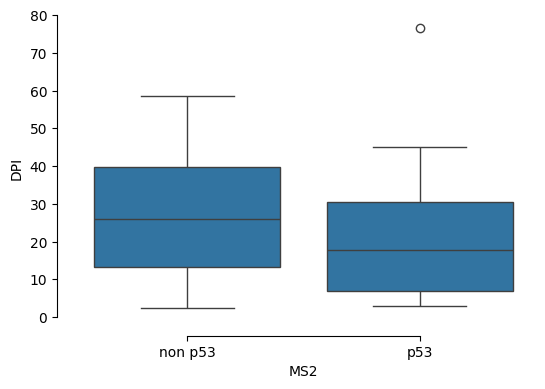

In [24]:
# Create the boxplot
plt.figure(figsize=(6, 4))
ax = sns.boxplot(data=dpi_results, x="MS2", y="DPI")
sns.despine(offset=10, trim=True)

### test spot frequency

In [25]:
%%capture
spot_cellfreq_df, spot_co_occurrence_df = eco.spot_cellfreq(spatial_data=df_all_anno,
                                                            scale=32.0,
                                                            library_key='tma_fov',
                                                            library_id=library_ids,
                                                            spatial_key=['X_cent','Y_cent'],
                                                            cluster_key='phenoBin',
                                                            spots='hot',
                                                            p_value=0.05,
                                                            top=None,
                                                            selected_comb=None,
                                                            restricted=False,
                                                            metric='Shannon Diversity')


In [26]:
spot_cellfreq_df['patientID'] = spot_cellfreq_df.index.map(region_to_patient)
spot_cellfreq_df['MS'] = spot_cellfreq_df.index.map(region_to_condition)

spot_co_occurrence_subcols = spot_co_occurrence_df.columns.tolist()
spot_co_occurrence_df['MS'] = spot_co_occurrence_df.index.map(region_to_condition)
spot_co_occurrence_df['patientID'] = spot_co_occurrence_df.index.map(region_to_patient)

spot_cellfreq_df['MS2'] = 'non p53'
spot_cellfreq_df.loc[spot_cellfreq_df.MS == 3,'MS2'] = 'p53'

In [39]:
### save the hotspot values
spot_cellfreq_df.to_csv('../hotspot_freq_BinTum.csv')

In [40]:
%%capture
spot_cellfreq_df, spot_co_occurrence_df = eco.spot_cellfreq(spatial_data=df_all_anno,
                                                            scale=32.0,
                                                            library_key='tma_fov',
                                                            library_id=library_ids,
                                                            spatial_key=['X_cent','Y_cent'],
                                                            cluster_key='phenoBin',
                                                            spots='cold',
                                                            p_value=0.05,
                                                            top=None,
                                                            selected_comb=None,
                                                            restricted=False,
                                                            metric='Shannon Diversity')


In [41]:
spot_cellfreq_df['patientID'] = spot_cellfreq_df.index.map(region_to_patient)
spot_cellfreq_df['MS'] = spot_cellfreq_df.index.map(region_to_condition)

spot_co_occurrence_subcols = spot_co_occurrence_df.columns.tolist()
spot_co_occurrence_df['MS'] = spot_co_occurrence_df.index.map(region_to_condition)
spot_co_occurrence_df['patientID'] = spot_co_occurrence_df.index.map(region_to_patient)

spot_cellfreq_df['MS2'] = 'non p53'
spot_cellfreq_df.loc[spot_cellfreq_df.MS == 3,'MS2'] = 'p53'

### save the hotspot values
spot_cellfreq_df.to_csv('../coldspot_freq_BinTum.csv')